In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from src.data_import import load_fashion_mnist

train_loader, test_loader = load_fashion_mnist(32, shuffle=True, class_subset=[9])

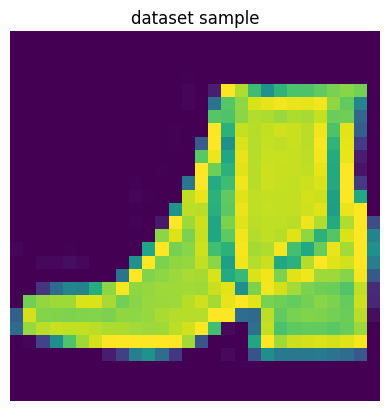

label: 9


In [3]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample")
#print label
print("label:", _[0].item())

In [4]:
from src.model import EnergyHead, EBM

n_heads = 4

model = EBM(in_dim=28*28, mid_dim=150, n_heads=n_heads, batch_size=32)


model.to(device)

EBM(
  (heads): ModuleList(
    (0-3): 4 x EnergyHead(
      (net): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
        (6): Flatten(start_dim=1, end_dim=-1)
        (7): Linear(in_features=3136, out_features=1, bias=True)
      )
    )
  )
)

In [5]:
from src.sampler import ReplaySampler
from src.information import TotalCorrelationEstimator

sampler = ReplaySampler(model, img_shape=(1, 28, 28), buffer_size=200, noise_fraction=0.05, device=device)
total_correlation_estimator = TotalCorrelationEstimator(n_heads)
total_correlation_estimator.to(device)

neg_samples = sampler.sample(batch_size=32, steps=10, step_size=0.1, noise_std=0.1)

In [ ]:
from src.train import train_one_epoch_TC
#torch.autograd.set_detect_anomaly(True, check_nan=False)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.0, 0.999))

for epoch in range(5):
    epoch_loss = train_one_epoch_TC(
        model, 
        total_correlation_estimator, 
        sampler, 
        train_loader, 
        optimizer,
        sample_steps=60,
        sample_step_size=10.0,
        sample_noise_std=0.005,
        energy_reg=0.5,
        tc_reg=0.1,
        device=device
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

 10%|▉         | 18/188 [00:57<09:04,  3.20s/it]


KeyboardInterrupt: 

In [ ]:
from src.diagnostic import diagnose

diagnose(model, sampler, train_loader, test_loader, device=device, n_samples=16)

In [ ]:
samples = sampler.generate(10, steps=200, step_size=10, noise_std=0.005)

In [ ]:
show_grid(samples, 10)